

SOSYAL İHTİYAÇ TAHMİN MODELİ (SOCIAL NEEDS PREDICTION MODEL)

Proje Amacı: Bireylerin sadece gelirlerine değil; aile yapısı, iş durumu ve 
psikolojik tatminlerine bakarak "Gerçek İhtiyaç Sahiplerini" tespit etmek.

Hedef (Target) Mimarısi - Hibrit Puanlama (Eşik >= 4):
1. Gelir (realinc) en alt %25'lik dilimde: +2 Puan
2. İş Durumu (wrkstat) İşsiz(4) veya Çalışmıyor(3): +2 Puan
3. Çocuk Sayısı (childs) 3 veya daha fazla: +1 Puan
4. Finansal Tatmin (satfin) "Hiç tatmin değil"(3): +1 Puan
5. Sosyal Sınıf (class) "Alt Sınıf"(1): +1 Puan

-4 puan ve üstü ihtiyacı var(1) olarak kabul edilir.


Kullanılan Özellikler (Features):
educ (Eğitim), prestg10 (Saygınlık), age (Yaş), sex (Cinsiyet), 
region (Bölge), marital (Medeni Durum), natfare (Sosyal Yardım Algısı)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
import joblib
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
!pip install imbalanced-learn
df = pd.read_csv('../data/processed/temiz_veri.csv')
df_sub = pd.read_csv('../data/processed/temiz_veri.csv')

1. VERİ HAZIRLIĞI VE EKSİK VERİ TAMAMLAMA

In [2]:
# Dosya yolunu kendi sistemine göre güncelle
df = pd.read_csv('../data/processed/temiz_veri.csv') 

# İşlem yapılacak sütunları garanti altına alalım
kategorik_sutunlar = ['wrkstat', 'satfin', 'class', 'sex', 'region', 'marital', 'natfare']
sayisal_sutunlar = ['realinc', 'childs', 'educ', 'prestg10', 'age']

# Sadece veri setinde var olan sütunları seçelim (Hata almamak için)
mevcut_sutunlar = [col for col in kategorik_sutunlar + sayisal_sutunlar if col in df.columns]
df = df[mevcut_sutunlar].copy()

# Sayısal boşlukları Medyan ile doldur
imputer_num = SimpleImputer(strategy='median')
df[[col for col in sayisal_sutunlar if col in df.columns]] = imputer_num.fit_transform(df[[col for col in sayisal_sutunlar if col in df.columns]])

# Kategorik boşlukları Mode (En sık geçen) ile doldur
imputer_cat = SimpleImputer(strategy='most_frequent')
df[[col for col in kategorik_sutunlar if col in df.columns]] = imputer_cat.fit_transform(df[[col for col in kategorik_sutunlar if col in df.columns]])

2. HİBRİT TARGET (HEDEF) İNŞASI

In [3]:
# Gelirin alt %25'lik sınırını df_sub (temizlenmiş veri) üzerinden buluyoruz
realinc_25th = df_sub['realinc'].quantile(0.25)

def calculate_need_score(row):
    score = 0
    # 1. Gelir alt %25'te ise (+2 Puan)
    if row['realinc'] <= realinc_25th:
        score += 2
    # 2. İşsiz (4) veya işi var ama çalışmıyor (3) ise (+2 Puan)
    if row['wrkstat'] in [3, 4]:
        score += 2
    # 3. Çocuk sayısı 3 veya fazlaysa (+1 Puan)
    if row['childs'] >= 3:
        score += 1
    # 4. Finansal olarak hiç tatmin değil (3) ise (+1 Puan)
    if row['satfin'] == 3:
        score += 1
    # 5. Alt sınıf (1) ise (+1 Puan)
    if row['class'] == 1:
        score += 1
    return score

# Skorları hesapla ve Target sütununu oluştur (Skor >= 4 ise 1, değilse 0)
# loc kullanmak df_sub üzerinde SettingWithCopyWarning hatası almanı engeller
df_sub.loc[:, 'need_score'] = df_sub.apply(calculate_need_score, axis=1)
df_sub.loc[:, 'target_money'] = (df_sub['need_score'] >= 4).astype(int)

# İşlemin başarılı olduğunu kontrol etmek için:
print("df_sub için target_money dağılımı:")
print(df_sub['target_money'].value_counts())
df_sub.loc[:, 'target_money'] = (df_sub['need_score'] >= 4).astype(int)

df_sub için target_money dağılımı:
target_money
0    20579
1     2077
Name: count, dtype: int64


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Güvenlik Kontrolü: Sütun yoksa hemen oluştur
if 'target_money' not in df_sub.columns:
    if 'natfare' in df_sub.columns:
        df_sub['target_money'] = np.where(df_sub['natfare'] == 1, 1, 0)
    else:
        print("HATA: natfare sütunu da bulunamadı. Veriyi en baştan yüklemeniz gerekiyor.")

# 2. X ve y Ayrımı
sizinti_yapan_sutunlar = ['realinc', 'wrkstat', 'childs', 'satfin', 'class', 'need_score', 'target_money', 'natfare']

X = df_sub.drop(columns=[col for col in sizinti_yapan_sutunlar if col in df_sub.columns])
y = df_sub['target_money']

# 3. Train-Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)   

print("İşlem başarılı. X_train boyutu:", X_train.shape)

İşlem başarılı. X_train boyutu: (18124, 14)


####    KEŞİFÇİ VERİ ANALİZİ

4. İhtiyacı Olanlar ve Olmayanların Sayısını Gösteren Grafik (Genel Dağılım)

Veri setindeki %90'a %10'luk o devasa sınıf dengesizliğini jüriye göstermek için en iyi yöntem bir pasta grafiği (Pie Chart) kullanmaktır.

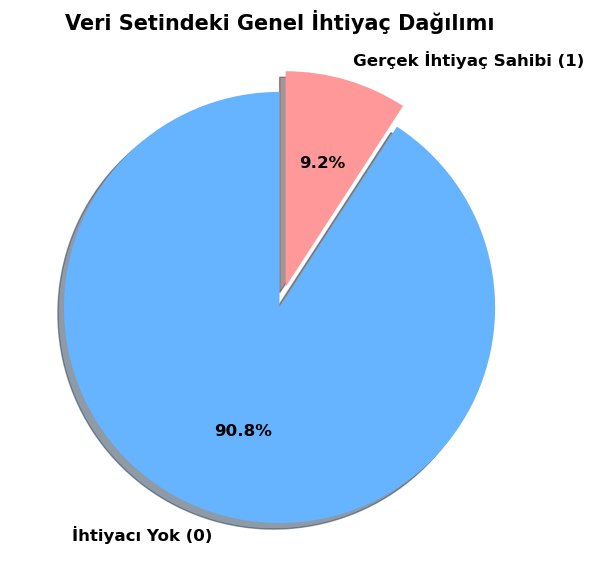

In [5]:
# Hata almamak için df_sub ve sütun kontrolü
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    plt.figure(figsize=(7, 7))

    # Hedef değişkenin sayımlarını df_sub üzerinden alıyoruz
    durum_sayilari = df_sub['target_money'].value_counts()

    # Pasta grafiği çizimi
    plt.pie(durum_sayilari, 
            labels=['İhtiyacı Yok (0)', 'Gerçek İhtiyaç Sahibi (1)'], 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=['#66b3ff', '#ff9999'], 
            explode=(0, 0.1), 
            shadow=True,
            textprops={'fontsize': 12, 'weight': 'bold'})

    plt.title('Veri Setindeki Genel İhtiyaç Dağılımı', fontsize=15, fontweight='bold')
    plt.show()
else:
    print("Hata: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı! Lütfen veriyi yüklediğinizden emin olun.")

1. Cinsiyete Göre Finansal Yardım İhtiyacı
Bu grafik, erkeklerin ve kadınların kendi içlerinde ne kadarının ihtiyaç sahibi olduğunu gösterir.

C:\Users\karac\AppData\Local\Temp\ipykernel_5832\1307259466.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_sub, x='sex', y='target_money', errorbar=None, palette='Set2')
C:\Users\karac\AppData\Local\Temp\ipykernel_5832\1307259466.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Kadın (0)', 'Erkek (1)'])


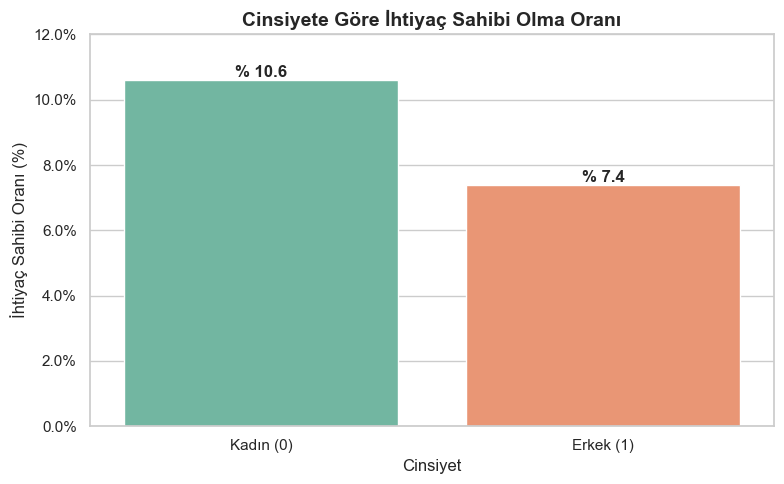

In [6]:
# Güvenlik Kontrolü: df_sub var mı ve içinde target_money sütunu mevcut mu?
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    
    # GÖRSELLEŞTİRME
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))

    # df yerine asıl çalışma masamız olan df_sub tablosunu kullanıyoruz
    ax = sns.barplot(data=df_sub, x='sex', y='target_money', errorbar=None, palette='Set2')

    plt.title('Cinsiyete Göre İhtiyaç Sahibi Olma Oranı', fontsize=14, fontweight='bold')
    plt.xlabel('Cinsiyet', fontsize=12)
    plt.ylabel('İhtiyaç Sahibi Oranı (%)', fontsize=12)

    # Eksen etiketleri (Verimizde 0: Kadın, 1: Erkek olarak güncellemiştik)
    ax.set_xticklabels(['Kadın (0)', 'Erkek (1)']) 

    # Y-Eksenini yüzde formatına çevirme (Hata almamak için önce yticks sabitlenir)
    vals = ax.get_yticks()
    ax.set_yticks(vals)
    ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

    # Çubukların üzerine yüzde değerlerini yazdıralım
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'% {height*100:.1f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("❌ HATA: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı! Lütfen veriyi yüklediğiniz hücreyi çalıştırın.")

2. Çocuk Sayısına Göre Finansal Yardım İhtiyacı
Çocuk sayısı arttıkça finansal yükün nasıl arttığını (bizim kurduğumuz mantığın nasıl çalıştığını) kanıtlayan grafiktir.

C:\Users\karac\AppData\Local\Temp\ipykernel_5832\1503071674.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_sub, x='childs', y='target_money', errorbar=None, palette='viridis')


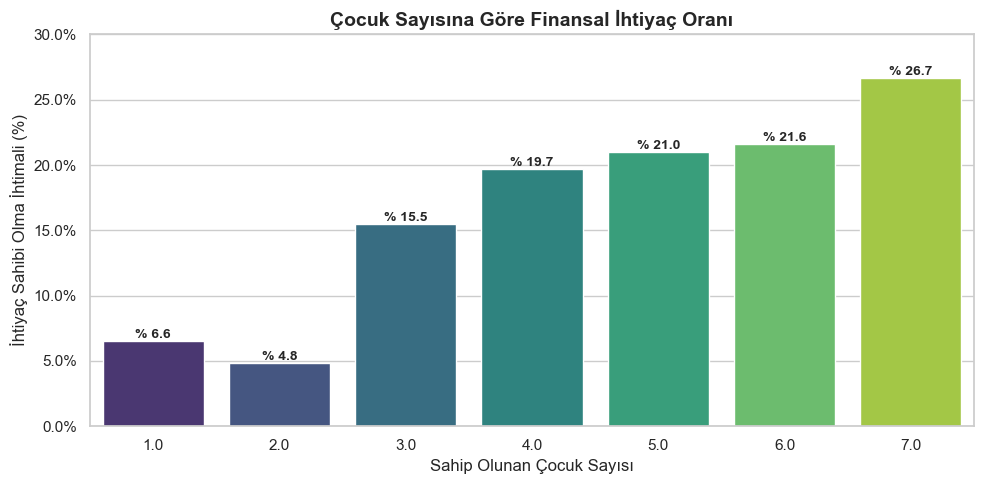

In [7]:
# 1. GÜVENLİK KONTROLÜ: df_sub var mı ve içinde target_money sütunu mevcut mu?
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    
    # 2. GRAFİK ÇİZİMİ
    plt.figure(figsize=(10, 5))
    
    # Veri kaynağı olarak df yerine df_sub kullanıyoruz
    ax = sns.barplot(data=df_sub, x='childs', y='target_money', errorbar=None, palette='viridis')

    plt.title('Çocuk Sayısına Göre Finansal İhtiyaç Oranı', fontsize=14, fontweight='bold')
    plt.xlabel('Sahip Olunan Çocuk Sayısı', fontsize=12)
    plt.ylabel('İhtiyaç Sahibi Olma İhtimali (%)', fontsize=12)

    # Y-Eksenini yüzde formatına çevirme (Uyarı almamak için yticks sabitlenir)
    vals = ax.get_yticks()
    ax.set_yticks(vals)
    ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

    # Çubukların üzerine yüzde değerlerini yazdıralım
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Sadece 0'dan büyük olanları yazdır (görsel kirliliği önler)
            ax.annotate(f"% {height*100:.1f}", 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("❌ HATA: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı!")
    print("ÇÖZÜM: Lütfen veriyi yüklediğiniz ve hedef değişkeni oluşturduğunuz ana hücreyi çalıştırın.")

3. Irk Gruplarına Göre Finansal Yardım İhtiyacı

 Farklı etnik grupların finansal kırılganlıklarını karşılaştırmak için kullanılır (GSS verisinde genellikle 1: Beyaz, 2: Siyah, 3: Diğer olarak kodlanır).

C:\Users\karac\AppData\Local\Temp\ipykernel_5832\2767631107.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_sub, x='race', y='target_money', errorbar=None, palette='magma')
C:\Users\karac\AppData\Local\Temp\ipykernel_5832\2767631107.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Beyaz (1)', 'Siyah (2)', 'Diğer (3)'])


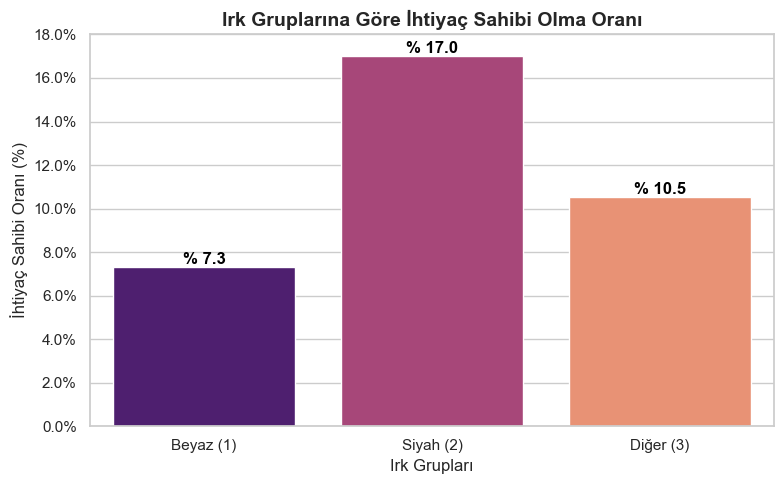

In [8]:
# 1. GÜVENLİK KONTROLÜ: df_sub var mı ve içinde target_money sütunu mevcut mu?
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    
    # 'race' sütununu orijinal dosyadan çekip df_sub'a ekliyoruz
    # (Eğer model sızıntısı yapmasın diye daha önce sildiysen, sadece görselleştirme için geri alıyoruz)
    df_orijinal = pd.read_csv('../data/processed/temiz_veri.csv')
    df_sub['race'] = df_orijinal['race']

    # 2. GRAFİK ÇİZİMİ
    plt.figure(figsize=(8, 5))
    sns.set_theme(style="whitegrid")

    # Veri kaynağı olarak df yerine df_sub kullanıyoruz ve ci=None güncellendi
    ax = sns.barplot(data=df_sub, x='race', y='target_money', errorbar=None, palette='magma')

    plt.title('Irk Gruplarına Göre İhtiyaç Sahibi Olma Oranı', fontsize=14, fontweight='bold')
    plt.xlabel('Irk Grupları', fontsize=12)
    plt.ylabel('İhtiyaç Sahibi Oranı (%)', fontsize=12)

    # X ekseni etiketlerini düzeltme
    ax.set_xticklabels(['Beyaz (1)', 'Siyah (2)', 'Diğer (3)'])

    # Y-Eksenini yüzde formatına çevirme (Uyarı almamak için yticks sabitlenir)
    vals = ax.get_yticks()
    ax.set_yticks(vals)
    ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

    # Yüzdeleri çubukların üzerine yazdırma
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Sadece 0'dan büyük olanları yazdır
            ax.annotate(f"% {height*100:.1f}", 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("❌ HATA: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı!")
    print("ÇÖZÜM: Lütfen veriyi yüklediğiniz ve hedef değişkeni oluşturduğunuz ana hücreyi çalıştırın.")

In [9]:
# df yerine temizlenmiş df_sub kullanıyoruz
sizinti_yapan_sutunlar = ['realinc', 'wrkstat', 'childs', 'satfin', 'class', 'need_score', 'target_money', 'natfare']

# Listede olan sütunları güvenlice düşür
X = df_sub.drop(columns=[col for col in sizinti_yapan_sutunlar if col in df_sub.columns])
y = df_sub['target_money']

# Train-Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Dosya yolunu kendi sistemine göre güncelle
df = pd.read_csv('../data/processed/temiz_veri.csv') 

# İşlem yapılacak sütunları garanti altına alalım
kategorik_sutunlar = ['wrkstat', 'satfin', 'class', 'sex', 'region', 'marital', 'natfare']
sayisal_sutunlar = ['realinc', 'childs', 'educ', 'prestg10', 'age']

# Sadece veri setinde var olan sütunları seçelim (Hata almamak için)
mevcut_sutunlar = [col for col in kategorik_sutunlar + sayisal_sutunlar if col in df.columns]
df = df[mevcut_sutunlar].copy()

# Sayısal boşlukları Medyan ile doldur
imputer_num = SimpleImputer(strategy='median')
df[[col for col in sayisal_sutunlar if col in df.columns]] = imputer_num.fit_transform(df[[col for col in sayisal_sutunlar if col in df.columns]])

# Kategorik boşlukları Mode (En sık geçen) ile doldur
imputer_cat = SimpleImputer(strategy='most_frequent')
df[[col for col in kategorik_sutunlar if col in df.columns]] = imputer_cat.fit_transform(df[[col for col in kategorik_sutunlar if col in df.columns]])

3. VERİ SIZINTISINI ÖNLEME VE AYIRMA

4. MODEL EĞİTİMİ VE OPTİMİZASYONU

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=8, 
    class_weight='balanced_subsample', 
    random_state=42
)
rf_model.fit(X_train, y_train)

# Dinamik Eşik (Threshold) Testi
y_probs = rf_model.predict_proba(X_test)[:, 1]
# Yeni puanlama sistemine göre eşiği ayarlıyoruz
final_score = balanced_accuracy_score(y_test, (y_probs >= 0.45).astype(int))

print(f"--- YENİ HİBRİT MODEL SONUCU ---")
print(f"Veri Seti Boyutu: {df.shape}")
print(f"Hedef (1) Olanların Sayısı: {y.sum()}")
print(f"Balanced Accuracy: {final_score:.4f}")

--- YENİ HİBRİT MODEL SONUCU ---
Veri Seti Boyutu: (22656, 12)
Hedef (1) Olanların Sayısı: 2077
Balanced Accuracy: 0.8317


In [11]:
from sklearn.metrics import classification_report

# Modelin test seti üzerindeki tahminlerini al
y_pred = rf_model.predict(X_test)

# Detaylı raporu yazdır
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.81      0.89      4117
           1       0.31      0.85      0.46       415

    accuracy                           0.82      4532
   macro avg       0.65      0.83      0.67      4532
weighted avg       0.92      0.82      0.85      4532



In [12]:
from lazypredict.Supervised import LazyClassifier

print("🚀 LazyClassifier başlatıldı. 30'a yakın algoritma birbiriyle yarışıyor, lütfen bekleyin...")

# Sınıf dengesizliği olduğu için modellerin temel ayarlarında çalışacak
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Tüm modelleri aynı X_train ve y_train ile eğit, test verisinde sına
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print("\n🏆 --- LAZY PREDICT LİDERLİK TABLOSU (İLK 10) --- 🏆")
print(models.head(10))

🚀 LazyClassifier başlatıldı. 30'a yakın algoritma birbiriyle yarışıyor, lütfen bekleyin...

🏆 --- LAZY PREDICT LİDERLİK TABLOSU (İLK 10) --- 🏆
                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
NearestCentroid                0.782657           0.743869  0.833244   
BernoulliNB                    0.878641           0.659111  0.865220   
GaussianNB                     0.891659           0.639192  0.813944   
DecisionTreeClassifier         0.864078           0.639178  0.639178   
XGBClassifier                  0.907105           0.626026  0.888375   
ExtraTreeClassifier            0.872021           0.618633  0.618633   
QuadraticDiscriminantAnalysis  0.897176           0.611894  0.812890   
LGBMClassifier                 0.910194           0.608225  0.901481   
LinearDiscriminantAnalysis     0.900265           0.603844  0.848468   
AdaBoostClassifier             0.907546           0.599184  0.887

--- DETAYLI MODEL KARNESİ ---
Gerçekte İhtiyacı Olmayan (0) ve Doğru Bilinen: 3247
Gerçekte İhtiyacı Olmayan (0) ama 1 Denilen (Yanlış Alarm): 870
Gerçekte İhtiyacı Olan (1) ama 0 Denilen (Gözden Kaçan): 52
Gerçekte İhtiyacı Olan (1) ve Doğru Bilinen (Net Başarı): 363
------------------------------

--- DEĞİŞKEN ÖNEM SIRALAMASI ---
               Değişken  Önem (%)
                 income     51.26
  Eğitim Seviyesi (Yıl)      9.30
           Medeni Durum      7.20
Mesleki Saygınlık Skoru      6.95
                  happy      5.19
                    Yaş      5.03
                 health      4.46
                 paeduc      2.85
                   race      1.87
               polviews      1.77
                   year      1.75
                  trust      0.96
        Yaşanılan Bölge      0.85
               Cinsiyet      0.56


C:\Users\karac\AppData\Local\Temp\ipykernel_5832\1501772613.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem (%)', y='Değişken', data=fi_df, palette='viridis')


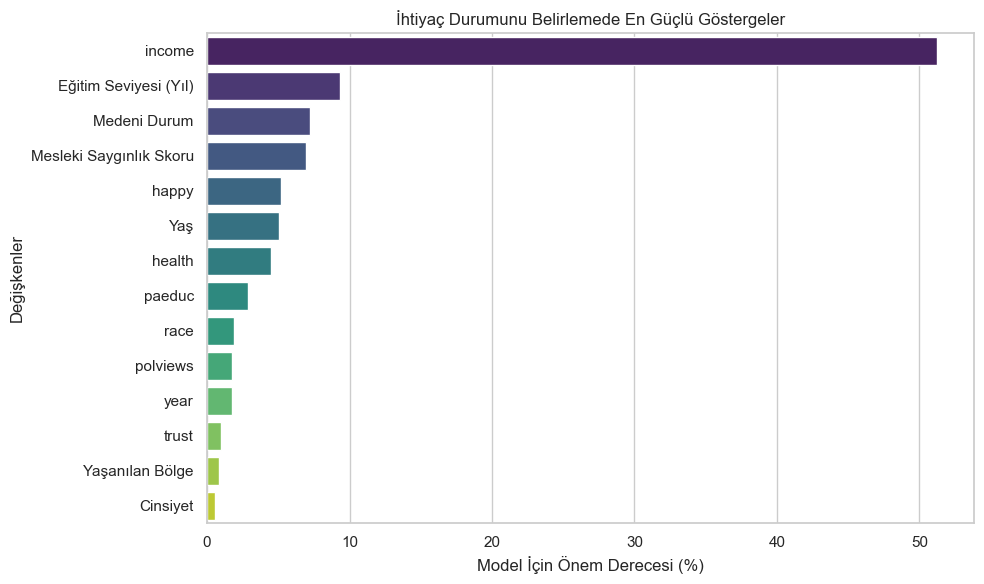

✅ Model başarıyla kaydedildi!


In [13]:
# 1. Hata Matrisi (Confusion Matrix) Analizi
y_pred = (y_probs >= 0.45).astype(int)
cm = confusion_matrix(y_test, y_pred)

print("--- DETAYLI MODEL KARNESİ ---")
print(f"Gerçekte İhtiyacı Olmayan (0) ve Doğru Bilinen: {cm[0][0]}")
print(f"Gerçekte İhtiyacı Olmayan (0) ama 1 Denilen (Yanlış Alarm): {cm[0][1]}")
print(f"Gerçekte İhtiyacı Olan (1) ama 0 Denilen (Gözden Kaçan): {cm[1][0]}")
print(f"Gerçekte İhtiyacı Olan (1) ve Doğru Bilinen (Net Başarı): {cm[1][1]}")
print("-" * 30)

# ==========================================
# 2. SÜTUN İSİMLERİNİ TÜRKÇELEŞTİRME SÖZLÜĞÜ
# ==========================================
# Bu sözlük, grafik ve raporlarda İngilizce isimleri Türkçe'ye çevirecek
turkce_isimler = {
    'educ': 'Eğitim Seviyesi (Yıl)',
    'prestg10': 'Mesleki Saygınlık Skoru',
    'age': 'Yaş',
    'sex': 'Cinsiyet',
    'region': 'Yaşanılan Bölge',
    'marital': 'Medeni Durum',
    'natfare': 'Sosyal Yardıma Bakış Açısı'
}

# 3. Hangi Değişkenler En Çok İşe Yaradı? (Feature Importance)
importances = rf_model.feature_importances_
feature_names = X_train.columns

# DataFrame'i oluştururken isimleri sözlükten çevir
fi_df = pd.DataFrame({
    'Değişken': [turkce_isimler.get(col, col) for col in feature_names], 
    'Önem (%)': importances * 100
}).sort_values(by='Önem (%)', ascending=False)

print("\n--- DEĞİŞKEN ÖNEM SIRALAMASI ---")
print(fi_df.to_string(index=False, float_format='%.2f'))

# 4. Türkçeleştirilmiş Grafik
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem (%)', y='Değişken', data=fi_df, palette='viridis')
plt.title('İhtiyaç Durumunu Belirlemede En Güçlü Göstergeler')
plt.xlabel('Model İçin Önem Derecesi (%)')
plt.ylabel('Değişkenler')
plt.tight_layout()
plt.show()

# 5. Başarılı Modeli Kaydet
print("✅ Model başarıyla kaydedildi!")

In [15]:
# 1. VERİ VE HEDEF HAZIRLIĞI
df_sub = pd.read_csv('../data/processed/temiz_veri.csv')
df_sub['target_money'] = np.where(df_sub['natfare'] == 1, 1, 0)

# 2. ÖZELLİK SEÇİMİ (Sızıntı sütunları hariç)
X = df_sub.drop(columns=['realinc', 'wrkstat', 'childs', 'satfin', 'class', 'need_score', 'target_money', 'natfare'], errors='ignore')
y = df_sub['target_money']

# 3. VERİYİ BÖLME
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. ÖN İŞLEME (LazyClassifier Standartı)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_scaled = scaler.transform(imputer.transform(X_test))

# 5. MODEL KURULUMU (Senin istediğin dengeli yapı)
model = LGBMClassifier(
    class_weight='balanced', # Sınıf dengesizliğini çözen kritik parametre
    random_state=42
)

model.fit(X_train_scaled, y_train)

# 6. SONUÇLAR
y_pred = model.predict(X_test_scaled)
print("--- Denge Ayarlı LGBM Sonuçları ---")
print(classification_report(y_test, y_pred))

--- Denge Ayarlı LGBM Sonuçları ---
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      3913
           1       0.21      0.56      0.31       619

    accuracy                           0.66      4532
   macro avg       0.56      0.62      0.54      4532
weighted avg       0.81      0.66      0.71      4532



c:\Users\karac\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
